# 10a · Monte Carlo Simülasyonu
**Probability Lab** · Simulation Module

---
> **Bu notebook'ta ne öğreneceğiz?**  
> Monte Carlo simülasyonu, 06a'da ispatladığımız **Büyük Sayılar Yasası'nın** doğrudan pratik
> uygulamasıdır: bir şeyin gerçek değerini (bir integral, bir olasılık, bir risk ölçüsü)
> analitik olarak hesaplamak zor veya imkânsızsa, **rastgele örnekleyip ortalamasını alarak**
> yaklaşık bir cevap bulabilirsin. Bu notebook'ta π sayısından finansal risk hesaplamasına
> kadar aynı temel fikrin nasıl işlediğini göreceğiz.

**Önkoşul:** Büyük Sayılar Yasası (06a), Merkezi Limit Teoremi (06b)  
**Veri:**  
- `insurance.csv` — Sağlık sigortası (risk simülasyonu için — 08'den kopyalaman gerekiyor)  
- Gerçek zamanlı hisse senedi verisi (`yfinance` kütüphanesi ile, internet bağlantısı gerekir)  
- π tahmini ve kumarhane simülasyonları için sentetik veri (dış kaynak gerekmez)  
**Araçlar:** Python (numpy, scipy, yfinance), R (base R), SQL (DuckDB)


---
## 1 · Temel Fikir: LLN'nin Pratik Uygulaması

06a'da ispatladık ki: $n$ arttıkça, örneklem ortalaması $\bar{X}_n$ gerçek beklenen değere
($\mu$) yakınsar. Monte Carlo simülasyonu bunu **tersine çevirip kullanır**: eğer bir şeyin
beklenen değerini ($E[f(X)]$) analitik olarak hesaplayamıyorsan (integral çok karmaşık,
kapalı-form çözüm yok), bunun yerine:

1. $X$'ten çok sayıda rastgele örnek çek ($x_1, x_2, \dots, x_n$)
2. Her birinde $f(x_i)$'yi hesapla
3. Bunların ortalamasını al:

$$E[f(X)] \approx \frac{1}{n}\sum_{i=1}^{n} f(x_i)$$

LLN, bu yaklaşımın $n\to\infty$ iken **gerçek değere yakınsayacağını garanti ediyor.** İşte
Monte Carlo'nun tüm matematiksel meşruiyeti bu kadar basit bir gözleme dayanıyor.

---
## 2 · Klasik Örnek: π Sayısını "Rastgele Nokta Atarak" Tahmin Etmek

**Fikir:** $[-1,1]\times[-1,1]$ karesinin içine rastgele noktalar at. Karenin alanı $4$'tür.
İçine çizilmiş birim çemberin alanı $\pi r^2 = \pi$'dir (r=1). Eğer noktalar kareye **eşit
olasılıkla** (uniform) düşüyorsa:

$$\frac{\text{Çemberin içine düşen nokta sayısı}}{\text{Toplam nokta sayısı}} \approx \frac{\text{Çemberin alanı}}{\text{Karenin alanı}} = \frac{\pi}{4}$$

Yani:
$$\pi \approx 4 \times \frac{\text{çember içindeki nokta sayısı}}{\text{toplam nokta sayısı}}$$

Bir noktanın çemberin içinde olup olmadığını kontrol etmek kolay: merkeze uzaklığı
($\sqrt{x^2+y^2}$) 1'den küçükse içeridedir. Bu, aslında bir **Bernoulli deneyi**
("içeride mi değil mi") ve $n$ arttıkça oranın gerçek $\pi/4$'e yakınsaması, tam olarak LLN.

---
## 3 · Yakınsama Hızı: Kaç Örnek Yeterli?

06b'de (CLT) gördüğümüz $SE=\sigma/\sqrt{n}$ kuralı burada da geçerli — Monte Carlo tahmininin
hatası, örnek sayısının **karekökü** ile küçülüyor:
$$\text{Hata} \propto \frac{1}{\sqrt{n}}$$

Bunun pratik sonucu can sıkıcı: hatayı 10 kat azaltmak için örnek sayısını **100 kat**
artırman gerekiyor. Bu yüzden Monte Carlo, hassas hesaplamalar için "yavaş ama genel amaçlı"
bir yöntem olarak bilinir — ama analitik çözümün mümkün olmadığı durumlarda **tek çaren**
olabilir.

---
## 4 · Genel Monte Carlo İntegrasyonu

π örneği aslında bir integralin özel hali. Genel olarak, karmaşık bir $\int_a^b g(x)\,dx$
integralini şöyle tahmin edebilirsin:

1. $[a,b]$ aralığından uniform rastgele $n$ nokta çek
2. Her noktada $g(x)$'i hesapla
3. Ortalamasını al, aralık uzunluğuyla çarp: $\int_a^b g(x)\,dx \approx (b-a)\times\frac{1}{n}\sum g(x_i)$

Bu yöntem, özellikle **yüksek boyutlu** integrallerde (10+ değişken) analitik/nümerik
yöntemlerin (Simpson kuralı gibi) çok yavaşladığı durumlarda devreye giriyor — Monte Carlo'nun
hata oranı boyut sayısından bağımsız olarak hep $1/\sqrt{n}$ kalıyor (bu, "boyutsallığın
laneti"ni kısmen aşan nadir yöntemlerden biri olmasının sebebi).

---
## 5 · Finansal Simülasyon: Geometric Brownian Motion ve VaR

Bir hisse senedi fiyatının zamanla nasıl değişebileceğini modellemek için yaygın kullanılan
bir stokastik süreç:
$$S_{t+1} = S_t \times \exp\left[\left(\mu - \frac{\sigma^2}{2}\right)\Delta t + \sigma\sqrt{\Delta t}\,Z_t\right], \quad Z_t \sim N(0,1)$$

Burada $\mu$ beklenen getiri, $\sigma$ volatilite. Bu formülü **binlerce kez** simüle edip
(her seferinde farklı rastgele $Z_t$'ler kullanarak), gelecekteki fiyatın **olası dağılımını**
elde edersin — tek bir tahmin değil, bir olasılık bulutu.

Bu dağılımdan **VaR (Value at Risk)** hesaplanır: "%95 güvenle, kaybım en fazla ne kadar
olur?" — bu, simüle edilmiş dağılımın alt %5'lik yüzdelik dilimidir. Risk yönetiminde
(bankacılık, portföy yönetimi) yaygın kullanılan bir metrik.

---
## 6 · MCMC'ye Kısa Bir Bakış: Basit Monte Carlo Ne Zaman Yetmez?

Şimdiye kadarki tüm örneklerde, $X$'ten **doğrudan örnekleyebiliyorduk** (uniform dağılımdan,
Normal dağılımdan). Ama 07b'de gördüğün gibi, bazı posterior dağılımların **eşlenik prior'u
yoktur** — o karmaşık dağılımdan doğrudan rastgele örnek çekmenin kolay bir yolu olmayabilir.

**MCMC (Markov Chain Monte Carlo)**, bu durumda devreye giriyor: dağılımdan doğrudan
örnekleyemesen bile, bir **Markov zinciri** kurup (her adım bir öncekine bağlı rastgele
yürüyüş), bu zincirin uzun vadede tam olarak istediğin dağılıma yakınsamasını sağlıyorsun.
Bu, ileri seviye bir konu (PyMC, Stan gibi kütüphanelerin temeli) — bu notebook'ta sadece
"neden var olduğunu" anlaman yeterli, detaylarına girmiyoruz.

---
## 7 · Özet Tablo

| Uygulama | Ne Tahmin Ediliyor | Yöntem |
|---|---|---|
| π tahmini | Bir geometrik sabit | Rastgele nokta + oran |
| Genel integrasyon | $\int g(x)dx$ | Rastgele örnekleme + ortalama |
| Finansal simülasyon | Gelecekteki fiyat dağılımı | GBM + binlerce yol simülasyonu |
| Risk (VaR) | "%95 güvenle max kayıp" | Simüle edilmiş dağılımın yüzdelik dilimi |
| MCMC | Karmaşık posterior dağılımlar | Markov zinciri ile dolaylı örnekleme |

---
# 🐍 Python Uygulaması

5 adımda ilerleyeceğiz:
1. **π Tahmini** — Klasik Monte Carlo demo, görsel + yakınsama
2. **Yakınsama Hızı** — 1/√n kuralının ampirik doğrulaması
3. **Genel Monte Carlo İntegrasyonu** — Kapalı formu bilinen bir integrali tahmin edip doğrulama
4. **Finansal Simülasyon (GBM + VaR)** — Gerçek hisse verisiyle risk hesaplama
5. **Sigorta Risk Simülasyonu** — Gerçek sigorta verisiyle portföy riski tahmini

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print('Hazır ✓')

Hazır ✓


---
### 🎯 Python 1 — π Tahmini: Klasik Monte Carlo Demo

**Ne yapıyoruz?**  
Bölüm 2'deki fikri uyguluyoruz: $[-1,1]\times[-1,1]$ karesine 10.000 rastgele nokta atıp,
kaçının birim çemberin içine düştüğünü sayarak π'yi tahmin ediyoruz.

Gerçek π: 3.141593
Monte Carlo tahmini (n=10000): 3.125600
Mutlak hata: 0.015993


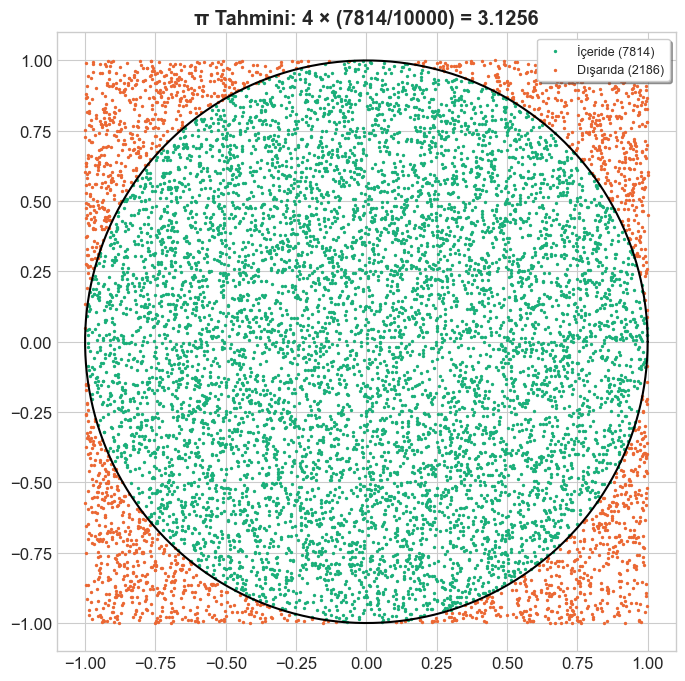

In [13]:
rng = np.random.default_rng(42)
n_points = 10000

x = rng.uniform(-1, 1, n_points)
y = rng.uniform(-1, 1, n_points)
mesafe = np.sqrt(x**2 + y**2)
iceride = mesafe <= 1

pi_tahmini = 4 * iceride.sum() / n_points
print(f"Gerçek π: {np.pi:.6f}")
print(f"Monte Carlo tahmini (n={n_points}): {pi_tahmini:.6f}")
print(f"Mutlak hata: {abs(np.pi - pi_tahmini):.6f}")

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(x[iceride], y[iceride], s=2, color='#1baf7a', label=f'İçeride ({iceride.sum()})')
ax.scatter(x[~iceride], y[~iceride], s=2, color='#eb6834', label=f'Dışarıda ({(~iceride).sum()})')
tetha = np.linspace(0, 2*np.pi, 200)
ax.plot(np.cos(tetha), np.sin(tetha), color='black', linewidth=1.5)
ax.set_aspect('equal')
ax.set_title(f'π Tahmini: 4 × ({iceride.sum()}/{n_points}) = {pi_tahmini:.4f}', fontweight='bold')
ax.legend(loc='upper right', fontsize=9, frameon=True, shadow=True)
plt.tight_layout()
plt.show()

---
### 📉 Python 2 — Yakınsama Hızı: 1/√n Kuralının Kanıtı

**Ne yapıyoruz?**  
Farklı $n$ değerleri için π tahminini tekrarlayıp, hatanın gerçekten $1/\sqrt{n}$ oranında
küçüldüğünü log-log ölçekte gösteriyoruz — düz bir çizgi çıkması, teorik oranın doğrulanması demek.

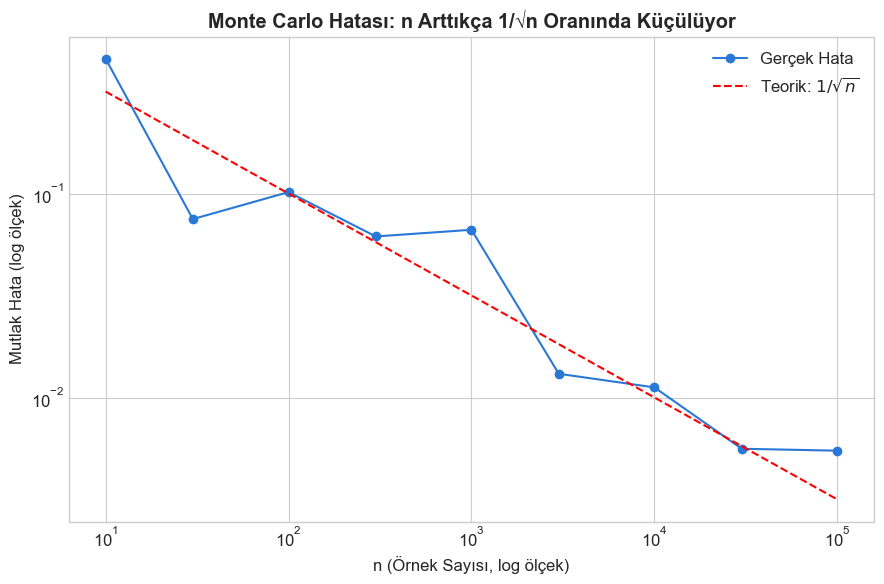

YORUM: Hata noktaları, teorik 1/√n çizgisiyle aynı eğimde iniyor (log-log grafikte
düz bir çizgi = güç yasası ilişkisi). Bu, CLT'nin öngördüğü √n kuralının Monte Carlo'da
da geçerli olduğunun görsel kanıtı.


In [14]:
n_degerleri = np.array([10, 30, 100, 300, 1000, 3000, 10000, 30000, 100000])
hatalar = []

for n in n_degerleri:
    x_n = rng.uniform(-1, 1, n)
    y_n = rng.uniform(-1, 1, n)
    iceride_n = (x_n**2 + y_n**2) <= 1
    pi_n = 4 * iceride_n.sum() / n
    hatalar.append(abs(np.pi - pi_n))

fig, ax = plt.subplots(figsize=(9, 6))
ax.loglog(n_degerleri, hatalar, 'o-', color='#2a78d6', label='Gerçek Hata')
ax.loglog(n_degerleri, 1/np.sqrt(n_degerleri), '--', color='red', label=r'Teorik: $1/\sqrt{n}$')
ax.set_xlabel('n (Örnek Sayısı, log ölçek)')
ax.set_ylabel('Mutlak Hata (log ölçek)')
ax.set_title('Monte Carlo Hatası: n Arttıkça 1/√n Oranında Küçülüyor', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print("YORUM: Hata noktaları, teorik 1/√n çizgisiyle aynı eğimde iniyor (log-log grafikte")
print("düz bir çizgi = güç yasası ilişkisi). Bu, CLT'nin öngördüğü √n kuralının Monte Carlo'da")
print("da geçerli olduğunun görsel kanıtı.")

---
### 🧮 Python 3 — Genel Monte Carlo İntegrasyonu

**Ne yapıyoruz?**  
Kapalı-form çözümünü zaten bildiğimiz bir integrali ($\int_0^\pi \sin(x)\,dx = 2$) Monte
Carlo ile tahmin edip, gerçek değerle karşılaştırıyoruz — "bilinen bir cevapla doğrulama"
tekniği, gerçek (bilinmeyen) bir integrali çözerken de güvenini kazanmanı sağlar.

Gerçek değer: 2.0

n=    10: Monte Carlo tahmini = 1.62990, hata = 0.37010
n=   100: Monte Carlo tahmini = 2.18126, hata = 0.18126
n=  1000: Monte Carlo tahmini = 1.94481, hata = 0.05519
n= 10000: Monte Carlo tahmini = 2.00866, hata = 0.00866
n=100000: Monte Carlo tahmini = 1.99809, hata = 0.00191


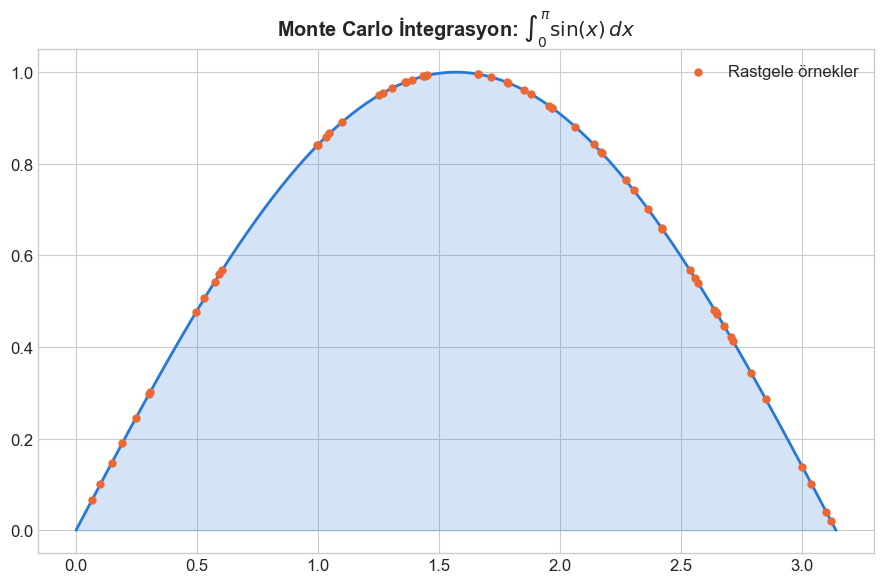

In [26]:
def g(x):
    return np.sin(x)

a, b = 0, np.pi
gercek_deger = 2.0  # integral_0^pi sin(x)dx = [-cos(x)]_0^pi = 2

n_values = [10, 100, 1000, 10000, 100000]
print(f"Gerçek değer: {gercek_deger}\n")
for n in n_values:
    x_samples = rng.uniform(a, b, n)
    tahmin = (b - a) * np.mean(g(x_samples))
    print(f"n={n:>6}: Monte Carlo tahmini = {tahmin:.5f}, hata = {abs(gercek_deger-tahmin):.5f}")

# Gorsel: fonksiyonun altindaki alan + rastgele noktalarin bir kismi
x_plot = np.linspace(a, b, 200)
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(x_plot, g(x_plot), color='#2a78d6', linewidth=2)
ax.fill_between(x_plot, g(x_plot), alpha=0.2, color='#2a78d6')
ornek_x = rng.uniform(a, b, 60)
ax.scatter(ornek_x, g(ornek_x), color='#eb6834', s=25, zorder=5, label='Rastgele örnekler')
ax.set_title(r'Monte Carlo İntegrasyon: $\int_0^\pi \sin(x)\,dx$', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

---
### 📈 Python 4 — Finansal Simülasyon: GBM ve Value at Risk

**Ne yapıyoruz?**  
`yfinance` ile gerçek bir hissenin geçmiş volatilitesini/getirisini alıp, Bölüm 5'teki GBM
formülüyle 1000 farklı "gelecek senaryosu" simüle ediyoruz, sonra %95 VaR'ı hesaplıyoruz.
İnternet bağlantısı yoksa/erişilemezse, sentetik (ama gerçekçi) parametrelerle devam ediyoruz.

Kaynak: AAPL (gerçek veri, yfinance)
S0=304.91, μ(yıllık)=0.2155, σ(yıllık)=0.2878

1 Yıl Sonraki Beklenen Fiyat: 379.58
%95 VaR: -0.2485 (-24.85%) - yani %95 güvenle, kaybın bundan fazla olmaz


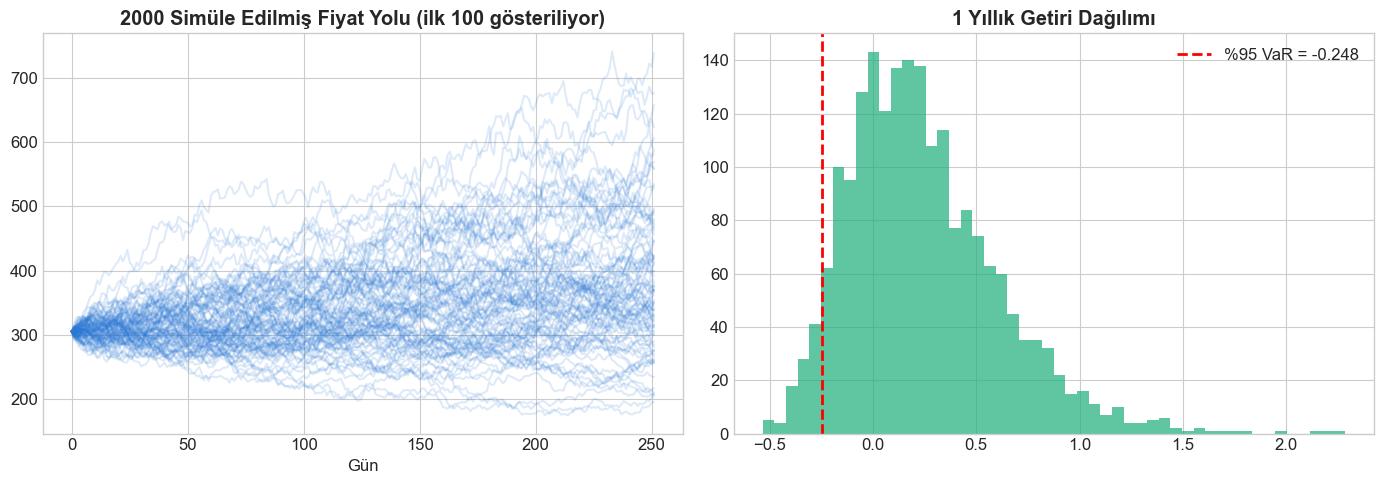

In [28]:
try:
    import yfinance as yf
    hisse = yf.download('AAPL', period='2y', progress=False)
    getiriler = hisse['Close'].pct_change().dropna()
    mu = getiriler.mean().item() * 252       # yıllıklandırılmış ortalama getiri
    sigma = getiriler.std().item() * np.sqrt(252)  # yıllıklandırılmış volatilite
    S0 = hisse['Close'].iloc[-1].item()
    kaynak = "AAPL (gerçek veri, yfinance)"
except Exception as e:
    print(f"yfinance'e erişilemedi ({e}) - sentetik ama gerçekçi parametrelerle devam ediyoruz.")
    mu, sigma, S0 = 0.10, 0.25, 150.0  # tipik bir hisse icin makul varsayimlar
    kaynak = "Sentetik (gerçekçi varsayımlar)"

print(f"Kaynak: {kaynak}")
print(f"S0={S0:.2f}, μ(yıllık)={mu:.4f}, σ(yıllık)={sigma:.4f}") # Mu = Ortalama Getiri, Sigma = Volatilite, S0 = Başlangıç Fiyatı

n_simulasyon = 2000
n_gun = 252  # 1 yil
dt = 1/252

rng2 = np.random.default_rng(7)
fiyat_yollari = np.zeros((n_simulasyon, n_gun))
fiyat_yollari[:, 0] = S0

for t in range(1, n_gun):
    Z = rng2.standard_normal(n_simulasyon)
    fiyat_yollari[:, t] = fiyat_yollari[:, t-1] * np.exp((mu - sigma**2/2)*dt + sigma*np.sqrt(dt)*Z)

son_fiyatlar = fiyat_yollari[:, -1]
getiri_dagilimi = (son_fiyatlar - S0) / S0

VaR_95 = np.percentile(getiri_dagilimi, 5)
print(f"\n1 Yıl Sonraki Beklenen Fiyat: {son_fiyatlar.mean():.2f}")
print(f"%95 VaR: {VaR_95:.4f} ({VaR_95*100:.2f}%) - yani %95 güvenle, kaybın bundan fazla olmaz")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i in range(100):
    axes[0].plot(fiyat_yollari[i], alpha=0.15, color='#2a78d6')
axes[0].set_title(f'{n_simulasyon} Simüle Edilmiş Fiyat Yolu (ilk 100 gösteriliyor)', fontweight='bold')
axes[0].set_xlabel('Gün')

axes[1].hist(getiri_dagilimi, bins=50, color='#1baf7a', alpha=0.7)
axes[1].axvline(VaR_95, color='red', linestyle='--', linewidth=2, label=f'%95 VaR = {VaR_95:.3f}')
axes[1].set_title('1 Yıllık Getiri Dağılımı', fontweight='bold')
axes[1].legend()
plt.tight_layout()
plt.show()

---
### 🏥 Python 5 — Sigorta Risk Simülasyonu

**Ne yapıyoruz?**  
`insurance.csv`'deki gerçek harcama dağılımından **bootstrap tarzı** tekrar örnekleme yaparak,
1000 kişilik farklı "portföylerin" toplam yıllık harcamasının nasıl dağıldığını simüle
ediyoruz — bir sigorta şirketinin "bu yıl toplam ne kadar ödeme yapabiliriz" sorusuna
Monte Carlo ile cevap vermesi gibi.

Gerçek veri: 1338 kişi, ortalama harcama: 13270.42

5000 simülasyon sonucu, 1000 kişilik portföyün toplam yıllık harcaması:
Ortalama: 13,266,433.05
Standart Sapma: 380,559.17

%95 senaryoda aşılmayacak toplam harcama: 13,901,811.56
%99 senaryoda aşılmayacak toplam harcama (daha temkinli): 14,169,923.62


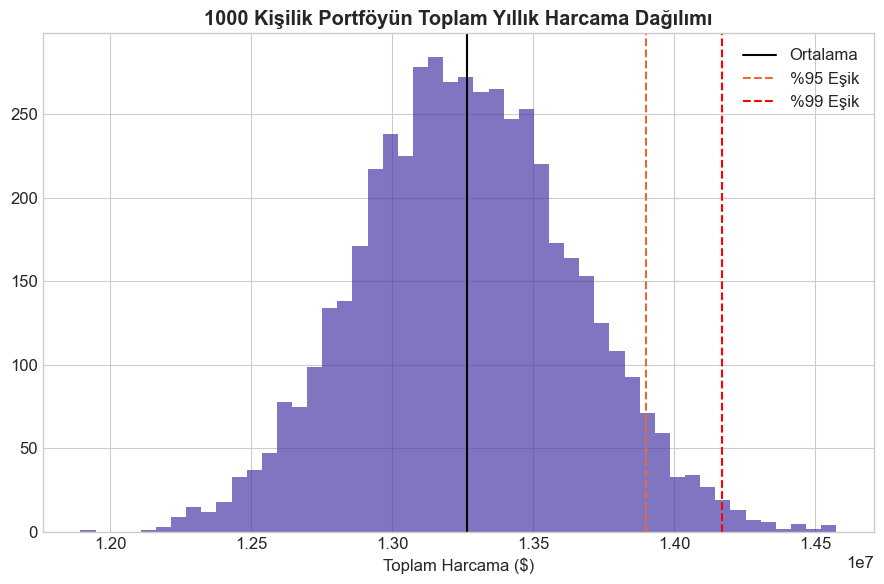


YORUM: Bu, CLT'nin de bir uygulaması aslında - 1000 kişilik toplam harcama, tekil
harcamalar çok çarpık olsa bile (charges dağılımı sağa çarpık), CLT sayesinde Normal'e
yakın bir dağılım gösteriyor. Sigorta şirketleri primlerini tam olarak böyle hesaplıyor.


In [29]:
insurance = pd.read_csv('data/insurance.csv')
charges = insurance['charges'].values
print(f"Gerçek veri: {len(charges)} kişi, ortalama harcama: {charges.mean():.2f}")

n_simulasyon = 5000
portfoy_buyuklugu = 1000  # her simulasyonda 1000 kisilik bir portfoy varsayalim

rng3 = np.random.default_rng(11)
toplam_harcamalar = np.zeros(n_simulasyon)
for i in range(n_simulasyon):
    ornek_portfoy = rng3.choice(charges, size=portfoy_buyuklugu, replace=True)  # bootstrap: yerine koyarak
    toplam_harcamalar[i] = ornek_portfoy.sum()

print(f"\n{n_simulasyon} simülasyon sonucu, {portfoy_buyuklugu} kişilik portföyün toplam yıllık harcaması:")
print(f"Ortalama: {toplam_harcamalar.mean():,.2f}")
print(f"Standart Sapma: {toplam_harcamalar.std():,.2f}")

VaR_95_sigorta = np.percentile(toplam_harcamalar, 95)
VaR_99_sigorta = np.percentile(toplam_harcamalar, 99)
print(f"\n%95 senaryoda aşılmayacak toplam harcama: {VaR_95_sigorta:,.2f}")
print(f"%99 senaryoda aşılmayacak toplam harcama (daha temkinli): {VaR_99_sigorta:,.2f}")

fig, ax = plt.subplots(figsize=(9, 6))
ax.hist(toplam_harcamalar, bins=50, color='#4a3aa7', alpha=0.7)
ax.axvline(toplam_harcamalar.mean(), color='black', linestyle='-', label='Ortalama')
ax.axvline(VaR_95_sigorta, color='#eb6834', linestyle='--', label='%95 Eşik')
ax.axvline(VaR_99_sigorta, color='red', linestyle='--', label='%99 Eşik')
ax.set_title(f'{portfoy_buyuklugu} Kişilik Portföyün Toplam Yıllık Harcama Dağılımı', fontweight='bold')
ax.set_xlabel('Toplam Harcama ($)')
ax.legend()
plt.tight_layout()
plt.show()

print("\nYORUM: Bu, CLT'nin de bir uygulaması aslında - 1000 kişilik toplam harcama, tekil")
print("harcamalar çok çarpık olsa bile (charges dağılımı sağa çarpık), CLT sayesinde Normal'e")
print("yakın bir dağılım gösteriyor. Sigorta şirketleri primlerini tam olarak böyle hesaplıyor.")

---
# 📊 R Uygulaması

Python'da işlediğimiz üç ana konuyu (π tahmini, sigorta risk simülasyonu, finansal/kumarhane
simülasyonu) R'da tekrarlıyoruz.

In [46]:
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


---
### 🎯 R 1 — π Tahmini

**Yeni R kavramı yok** — `runif()` fonksiyonu, Python'daki `rng.uniform()`'un R karşılığı.

Gerçek π: 3.141593 
R'da Monte Carlo tahmini: 3.1272 
Mutlak hata: 0.01439265 


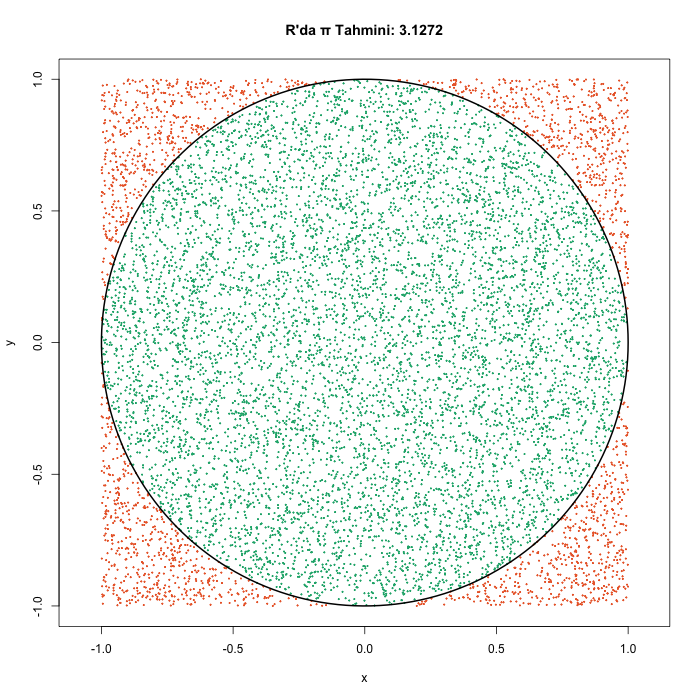

In [31]:
%%R -w 700 -h 700

set.seed(42)
n_points <- 10000

x <- runif(n_points, -1, 1)
y <- runif(n_points, -1, 1)
mesafe <- sqrt(x^2 + y^2)
iceride <- mesafe <= 1

pi_tahmini <- 4 * sum(iceride) / n_points
cat("Gerçek π:", pi, "\n")
cat("R'da Monte Carlo tahmini:", pi_tahmini, "\n")
cat("Mutlak hata:", abs(pi - pi_tahmini), "\n")

plot(x[iceride], y[iceride], col = "#1baf7a", pch = 20, cex = 0.3, asp = 1,
     main = paste("R'da π Tahmini:", round(pi_tahmini, 4)), xlab = "x", ylab = "y")
points(x[!iceride], y[!iceride], col = "#eb6834", pch = 20, cex = 0.3)
theta <- seq(0, 2*pi, length.out = 200)
lines(cos(theta), sin(theta), col = "black", lwd = 2)

---
### 🏥 R 2 — Sigorta Risk Simülasyonu

**Yeni R kavramı:** `sample(x, size, replace=TRUE)` içindeki `replicate()` ile döngüsüz bir
şekilde binlerce simülasyonu tek satırda çalıştırma.

Ortalama: 13267150 
%95 Eşik (VaR): 13902833 
%99 Eşik (VaR): 14185765 


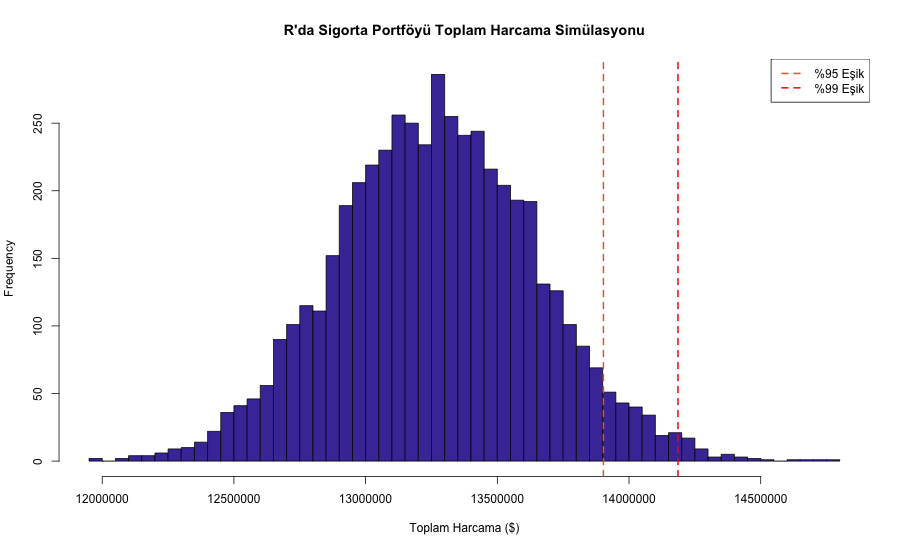

In [32]:
%%R -i insurance -w 900 -h 550

charges_r <- insurance$charges
n_simulasyon <- 5000
portfoy_buyuklugu <- 1000

set.seed(11)
toplam_harcamalar <- replicate(n_simulasyon, sum(sample(charges_r, portfoy_buyuklugu, replace = TRUE)))

cat("Ortalama:", mean(toplam_harcamalar), "\n")
cat("%95 Eşik (VaR):", quantile(toplam_harcamalar, 0.95), "\n")
cat("%99 Eşik (VaR):", quantile(toplam_harcamalar, 0.99), "\n")

hist(toplam_harcamalar, breaks = 50, col = "#4a3aa7",
     main = "R'da Sigorta Portföyü Toplam Harcama Simülasyonu",
     xlab = "Toplam Harcama ($)")
abline(v = quantile(toplam_harcamalar, 0.95), col = "#eb6834", lwd = 2, lty = 2)
abline(v = quantile(toplam_harcamalar, 0.99), col = "red", lwd = 2, lty = 2)
legend("topright", legend = c("%95 Eşik", "%99 Eşik"), col = c("#eb6834", "red"), lty = 2, lwd = 2)

---
### 🎰 R 3 — Kumarhane Simülasyonu: Ev Kenarı (House Edge) LLN İle Ortaya Çıkıyor

**Ne yapıyoruz?**  
Amerikan ruletinde 38 bölme var (1-36, 0, 00), tek bir sayıya bahis yaptığında kazanma
olasılığın $1/38$, ama ödeme oranı 35 katı — bu, kumarhanenin lehine küçük ama kalıcı bir
matematiksel avantaj (~%5.26) yaratıyor. Az sayıda oyunda şansa bağlı kazanabilirsin, ama
LLN sayesinde çok sayıda oyunda bu avantaj **kaçınılmaz** hale geliyor.

Teorik beklenen değer (tek oyun başına): -0.05263158 
Simülasyon sonucu (n=10000 oyun) ortalama kazanç/oyun: -0.0712 
Toplam net kazanç/kayıp: -712 


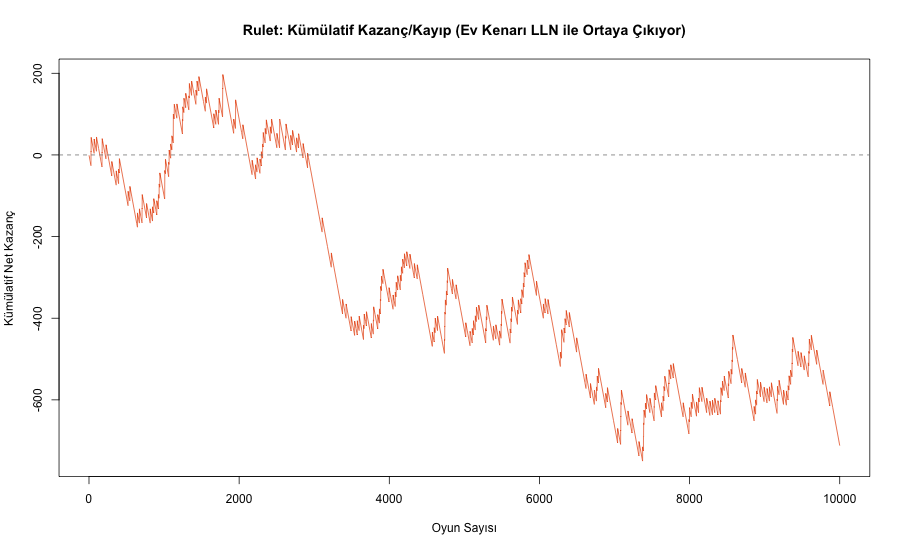

In [33]:
%%R -w 900 -h 550

set.seed(99)
n_oyun <- 10000
bahis <- 1  # her oyunda 1 birim bahis

# Tek sayiya bahis: 1/38 kazanma sansi, kazaninca 35 birim kar (+bahis geri), kaybedince -1
kazanma_olasiligi <- 1/38
sonuclar <- ifelse(runif(n_oyun) < kazanma_olasiligi, 35, -1)
kumulatif_kazanc <- cumsum(sonuclar)

cat("Teorik beklenen değer (tek oyun başına):", 35 * (1/38) + (-1) * (37/38), "\n")
cat("Simülasyon sonucu (n=10000 oyun) ortalama kazanç/oyun:", mean(sonuclar), "\n")
cat("Toplam net kazanç/kayıp:", sum(sonuclar), "\n")

plot(1:n_oyun, kumulatif_kazanc, type = "l", col = "#eb6834",
     main = "Rulet: Kümülatif Kazanç/Kayıp (Ev Kenarı LLN ile Ortaya Çıkıyor)",
     xlab = "Oyun Sayısı", ylab = "Kümülatif Net Kazanç")
abline(h = 0, col = "gray50", lty = 2)

---
# 🗄️ SQL Uygulaması (DuckDB)

DuckDB'nin `random()` fonksiyonu (0-1 arası uniform rastgele sayı üretir), Monte Carlo
simülasyonunun temel yapı taşı — π tahminini ve sigorta risk simülasyonunu SQL içinde
tekrarlayabiliyoruz.

In [34]:
import duckdb
con = duckdb.connect()
con.register('insurance_tbl', insurance)
print('DuckDB hazır ✓')

DuckDB hazır ✓


---
### 🎯 SQL 1 — π Tahmini

**Ne yapıyoruz?**  
`generate_series` ile 100.000 "deneme" satırı üretip, her satırda iki rastgele koordinat
(`random()` ile) çekip çemberin içinde olup olmadığını `CASE WHEN` ile kontrol ediyoruz.

In [35]:
sql_pi = con.execute("""
    WITH denemeler AS (
        SELECT
            random() * 2 - 1 AS x,
            random() * 2 - 1 AS y
        FROM range(100000)
    )
    SELECT
        4.0 * SUM(CASE WHEN x*x + y*y <= 1 THEN 1 ELSE 0 END) / COUNT(*) AS pi_tahmini,
        COUNT(*) AS n
    FROM denemeler
""").df()

print(sql_pi.to_string(index=False))
print(f"\nGerçek π: {np.pi:.6f}")
print(f"SQL'deki tahminle fark: {abs(np.pi - sql_pi['pi_tahmini'][0]):.6f}")

 pi_tahmini      n
     3.1396 100000

Gerçek π: 3.141593
SQL'deki tahminle fark: 0.001993


---
### 🏥 SQL 2 — Sigorta Risk Simülasyonu (Basitleştirilmiş)

**Ne yapıyoruz?**  
Tam bootstrap'ı (yerine koyarak binlerce kez 1000 kişi seçmek) saf SQL'de verimli yapmak
zor olduğu için, burada SQL'in gücünü **tek bir büyük örneklemin özet istatistiklerini**
hesaplamakta kullanıyoruz — bu, Monte Carlo'nun "veriyi hazırlama" kısmına SQL'in nasıl
katkı sağladığının bir örneği.

In [36]:
sql_insurance_stats = con.execute("""
    SELECT
        COUNT(*) AS n_kisi,
        ROUND(AVG(charges), 2) AS ortalama_harcama,
        ROUND(STDDEV_POP(charges), 2) AS std_harcama,
        ROUND(QUANTILE_CONT(charges, 0.95), 2) AS p95_bireysel_harcama,
        ROUND(SUM(charges), 2) AS toplam_gercek_harcama
    FROM insurance_tbl
""").df()

print(sql_insurance_stats.to_string(index=False))

# Bu istatistikleri kullanarak, CLT'den bekledigimiz "1000 kisilik portfoy toplami"
# yaklasik dagilimini analitik olarak da tahmin edebiliriz (Monte Carlo'ya alternatif olarak)
n_port = 1000
mu_toplam = sql_insurance_stats['ortalama_harcama'][0] * n_port
sigma_toplam = sql_insurance_stats['std_harcama'][0] * np.sqrt(n_port)
print(f"\nCLT ile analitik tahmin: Toplam ~ N({mu_toplam:,.0f}, {sigma_toplam:,.0f}²)")
print(f"Python 5'teki Monte Carlo ortalamasıyla karşılaştır - yakın çıkmalı.")

 n_kisi  ortalama_harcama  std_harcama  p95_bireysel_harcama  toplam_gercek_harcama
   1338          13270.42     12105.48              41181.83            17755824.99

CLT ile analitik tahmin: Toplam ~ N(13,270,420, 382,809²)
Python 5'teki Monte Carlo ortalamasıyla karşılaştır - yakın çıkmalı.


---
### 🎰 SQL 3 — Rulet Simülasyonu

**Ne yapıyoruz?**  
R 3'teki ruleti SQL'de tekrarlıyoruz — `CASE WHEN random() < 1.0/38 THEN 35 ELSE -1 END`
kalıbıyla, her satır bir oyun turu.

In [37]:
sql_rulet = con.execute("""
    WITH oyunlar AS (
        SELECT
            i AS oyun_no,
            CASE WHEN random() < 1.0/38 THEN 35 ELSE -1 END AS sonuc
        FROM range(10000) AS t(i)
    )
    SELECT
        COUNT(*) AS toplam_oyun,
        SUM(sonuc) AS toplam_net_kazanc,
        ROUND(AVG(sonuc), 4) AS oyun_basi_ortalama,
        ROUND(AVG(sonuc) * 100, 2) AS ev_kenari_yuzde
    FROM oyunlar
""").df()

print(sql_rulet.to_string(index=False))
teorik_beklenen = 35 * (1/38) + (-1) * (37/38)
print(f"\nTeorik beklenen değer (oyun başına): {teorik_beklenen:.4f}")
print("SQL simülasyonundaki 'oyun_basi_ortalama' bu teorik değere yakın çıkmalı.")

 toplam_oyun  toplam_net_kazanc  oyun_basi_ortalama  ev_kenari_yuzde
       10000             -316.0             -0.0316            -3.16

Teorik beklenen değer (oyun başına): -0.0526
SQL simülasyonundaki 'oyun_basi_ortalama' bu teorik değere yakın çıkmalı.


---
## ✏️ Egzersizler

### **E1 (Python) - Monte Carlo ile $\int_1^3 x^2\,dx$'i tahmin et**
(gerçek değeri elle hesaplayabilirsin: $\left[\frac{x^3}{3}\right]_1^3 = \frac{26}{3} \approx 8.667$). Farklı
$n$ değerleri için hatanın nasıl küçüldüğünü Python 2'deki gibi log-log grafikte göster.

Gerçek değer: 8.666666666666666

n=    10: Monte Carlo tahmini = 9.93512, hata = 1.26846
n=   100: Monte Carlo tahmini = 8.93818, hata = 0.27152
n=  1000: Monte Carlo tahmini = 8.39935, hata = 0.26732
n= 10000: Monte Carlo tahmini = 8.67159, hata = 0.00493
n=100000: Monte Carlo tahmini = 8.66664, hata = 0.00002


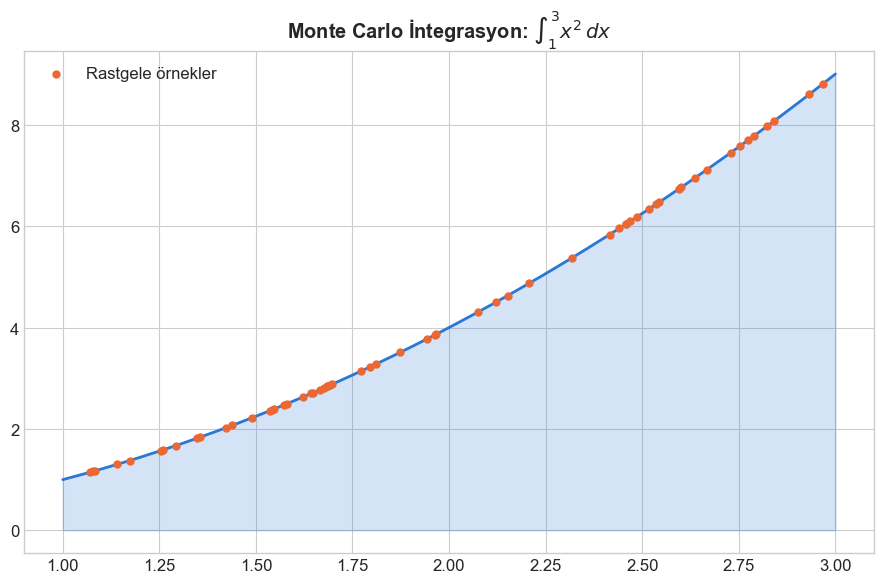

In [38]:
def g(x):
    return x*x

a, b = 1, 3
gercek_deger = (b**3 - a**3) / 3  # integral_1^3 x^2 dx = [x^3/3]_1^3

n_values = [10, 100, 1000, 10000, 100000]
print(f"Gerçek değer: {gercek_deger}\n")
for n in n_values:
    x_samples = rng.uniform(a, b, n)
    tahmin = (b - a) * np.mean(g(x_samples))
    print(f"n={n:>6}: Monte Carlo tahmini = {tahmin:.5f}, hata = {abs(gercek_deger-tahmin):.5f}")

x_plot = np.linspace(a, b, 200)
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(x_plot, g(x_plot), color='#2a78d6', linewidth=2)
ax.fill_between(x_plot, g(x_plot), alpha=0.2, color='#2a78d6')
ornek_x = rng.uniform(a, b, 60)
ax.scatter(ornek_x, g(ornek_x), color='#eb6834', s=25, zorder=5, label='Rastgele örnekler')
ax.set_title(r'Monte Carlo İntegrasyon: $\int_1^3 x^2\,dx$', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

---
### **E2 (Python + SQL) - Portföy Büyüklüğü ile Monte Carlo Risk Simülasyonu** 
`insurance.csv`'de portföy büyüklüğünü 1000 yerine 100 ve 5000 olarak değiştirip Monte Carlo risk simülasyonunu **hem Python'da hem SQL'in verdiği CLT-tabanlı analitik tahminle** tekrarla. Portföy büyüklüğü arttıkça VaR'ın (göreceli olarak) nasıl
davrandığını yorumla.



In [41]:
n_simulasyon = 5000
portfoy_buyuklukleri = [100, 1000, 5000]  # farklı portföy büyüklükleri için simülasyon

rng3 = np.random.default_rng(11)
toplam_harcamalar_dict = {}
for portfoy_buyuklugu in portfoy_buyuklukleri:
    toplam_harcamalar = np.zeros(n_simulasyon)
    for i in range(n_simulasyon):
        ornek_portfoy = rng3.choice(charges, size=portfoy_buyuklugu, replace=True)  # bootstrap: yerine koyarak
        toplam_harcamalar[i] = ornek_portfoy.sum()
    toplam_harcamalar_dict[portfoy_buyuklugu] = toplam_harcamalar

print(f"{n_simulasyon} simülasyon sonucu, farklı portföy büyüklükleri için toplam yıllık harcama:")
for portfoy_buyuklugu in portfoy_buyuklukleri:
    toplam_harcamalar = toplam_harcamalar_dict[portfoy_buyuklugu]
    print(f"\nPortföy büyüklüğü: {portfoy_buyuklugu}")
    print(f"Ortalama: {toplam_harcamalar.mean():,.2f}")
    print(f"Standart Sapma: {toplam_harcamalar.std():,.2f}")

sql_insurance_stats = con.execute("""
    SELECT
        COUNT(*) AS n_kisi,
        ROUND(AVG(charges), 2) AS ortalama_harcama,
        ROUND(STDDEV_POP(charges), 2) AS std_harcama
    FROM insurance_tbl
""").df()

n_ports = [100, 1000, 5000]
for n_port in n_ports:
    mu_toplam = sql_insurance_stats['ortalama_harcama'][0] * n_port
    sigma_toplam = sql_insurance_stats['std_harcama'][0] * np.sqrt(n_port)
    print(f"\nCLT ile analitik tahmin: Portföy büyüklüğü {n_port} için Toplam ~ N({mu_toplam:,.0f}, {sigma_toplam:,.0f}²)")

5000 simülasyon sonucu, farklı portföy büyüklükleri için toplam yıllık harcama:

Portföy büyüklüğü: 100
Ortalama: 1,327,304.80
Standart Sapma: 121,696.07

Portföy büyüklüğü: 1000
Ortalama: 13,266,308.87
Standart Sapma: 381,131.10

Portföy büyüklüğü: 5000
Ortalama: 66,352,822.15
Standart Sapma: 859,775.28

CLT ile analitik tahmin: Portföy büyüklüğü 100 için Toplam ~ N(1,327,042, 121,055²)

CLT ile analitik tahmin: Portföy büyüklüğü 1000 için Toplam ~ N(13,270,420, 382,809²)

CLT ile analitik tahmin: Portföy büyüklüğü 5000 için Toplam ~ N(66,352,100, 855,987²)


---
### **E3 (Python + R) - Hafızasızlık** 
Bölüm 6'da bahsedilen "hafızasızlık" kavramına dönerek, bir
Martingale bahis stratejisini (her kaybedişte bahsi 2 katına çıkarma) simüle et — üç dilde
de 10.000 oyunluk bir Martingale simülasyonu yap ve nihai sonucun hâlâ ev kenarına yenik
düştüğünü göster (ipucu: bahis limitini/bakiyeyi sınırlı tut, yoksa sonsuz bahis gerekir).


 ==== Egzersiz 3: Martingale Stratejisi ile Rulet Oyunu Simülasyonu ====


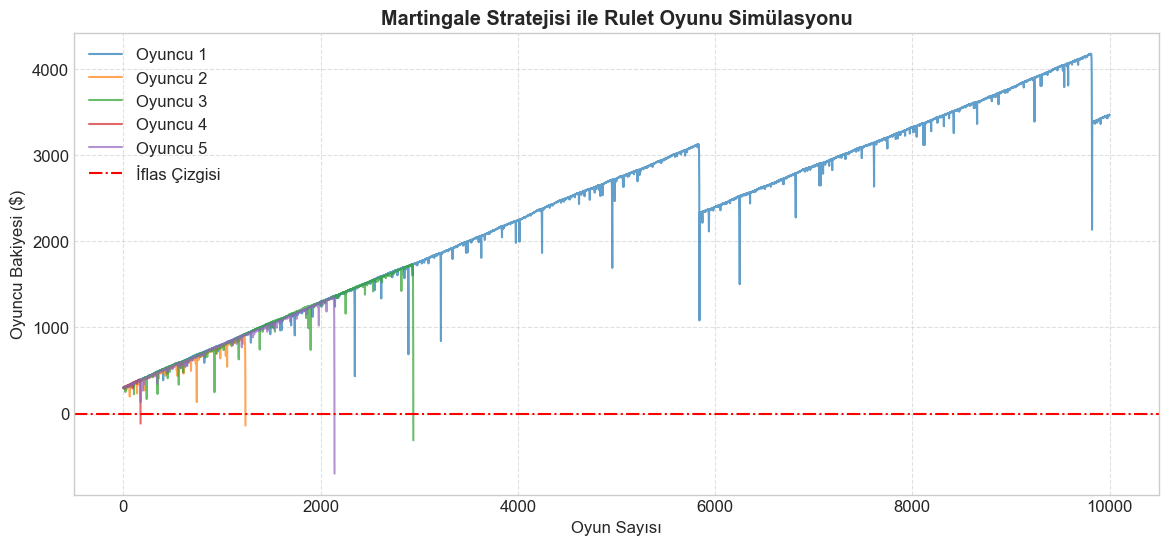

In [47]:
print("\n ==== Egzersiz 3: Martingale Stratejisi ile Rulet Oyunu Simülasyonu ====")

# Simülasyon Parametreleri
np.random.seed(13)  # Sonuçların tekrarlanabilir olması için sabit seed
bakiye = 300  # Başlangıçta 250 dolar
max_bahis = 1250  # Maksimum bahis limiti (Masa limiti)
oyun_sayisi = 10000 # Toplam oyun sayısı


def martingale_rulet(baslangic_bakiye, max_bahis, oyun_sayisi):
    bakiye = baslangic_bakiye
    bahis = 1
    bakiye_takip = [bakiye]  # Başlangıç bakiyesini de grafikte görmek için ekledik

    for oyun in range(oyun_sayisi):
        if bakiye <= 0:
            break  # Bakiye bitti, iflas durumu

        # Rulet sonucu: 18/37 kazan (+1), 19/37 kaybet (-1) (Avrupa Ruleti)
        sonuc = np.random.choice([1, -1], p=[18 / 37, 19 / 37])

        if sonuc == 1:  # Kazandı
            bakiye += bahis
            bahis = 1  # Bahis başlangıç değerine sıfırlanır
        else:  # Kaybetti
            bakiye -= bahis
            bahis = min(
                bahis * 2, max_bahis
            )  # Bahsi iki katına çıkar, masa limitini aşamaz

        bakiye_takip.append(bakiye)

    return bakiye_takip


# Simülasyonu Çalıştırma ve Görselleştirme
plt.figure(figsize=(14, 6))

for i in range(5):  # 5 farklı oyuncu simülasyonu
    bakiye_takip = martingale_rulet(bakiye, max_bahis, oyun_sayisi)
    plt.plot(bakiye_takip, label=f"Oyuncu {i+1}", alpha=0.7)

plt.title("Martingale Stratejisi ile Rulet Oyunu Simülasyonu", fontweight="bold")
plt.xlabel("Oyun Sayısı")
plt.ylabel("Oyuncu Bakiyesi ($)")  # Eksik olan y ekseni etiketi eklendi
plt.grid(True, linestyle="--", alpha=0.6)  # Grafiğin okunabilirliği için kılavuz çizgileri
plt.axhline(
    y=0, color="r", linestyle="-.", label="İflas Çizgisi"
)  # İflas sınırını gösteren kırmızı çizgi

plt.legend()
plt.show()


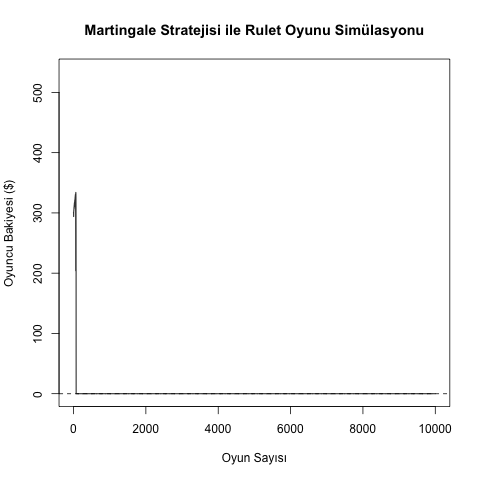

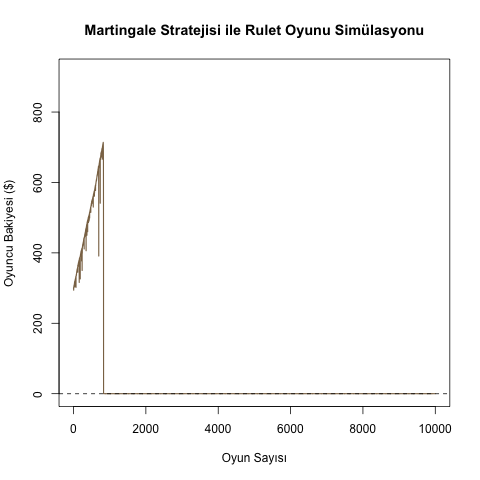

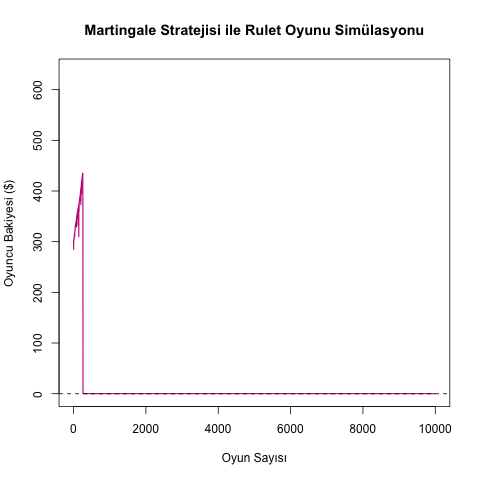

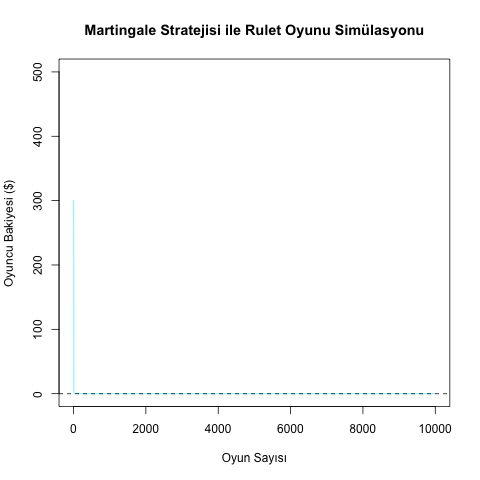

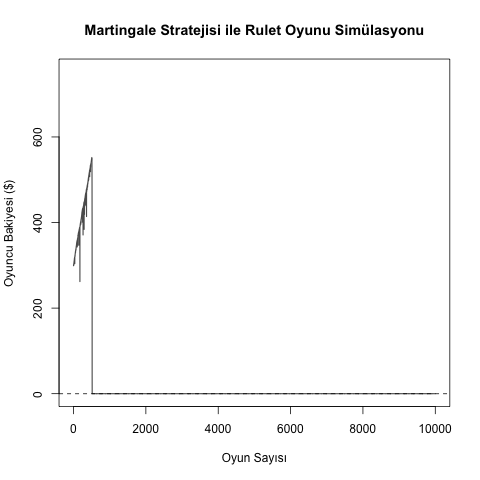

In [51]:
%%R
set.seed(13)
baslangic_bakiye <- 300
max_bahis <- 1250
oyun_sayisi <- 10000

# 1. Fonksiyon Tanımının Düzeltilmesi (R Sözdizimi)
martingale_rulet <- function(baslangic_bakiye, max_bahis, oyun_sayisi) {
    bakiye <- baslangic_bakiye
    bahis <- 1
    bakiye_takip <- numeric(oyun_sayisi + 1)
    bakiye_takip[1] <- bakiye

    for (oyun in 1:oyun_sayisi) {
        # Eğer bakiye eldeki bahisten azsa veya sıfırlanmışsa oyun biter
        if (bakiye <= 0 || bakiye < bahis) {
            # Kalan adımları sıfır olarak doldur ve döngüden çık
            bakiye_takip[(oyun + 1):(oyun_sayisi + 1)] <- 0
            break
        }

        sonuc <- sample(c(1, -1), 1, prob = c(18/37, 19/37))

        if (sonuc == 1) {
            bakiye <- bakiye + bahis
            bahis <- 1  # Kazanınca başlangıç bahsine dön
        } else {
            bakiye <- bakiye - bahis
            bahis <- min(bahis * 2, max_bahis)  # Kaybedince 2 katına çıkar (Limit korumalı)
        }

        bakiye_takip[oyun + 1] <- bakiye
    }
    return(bakiye_takip) # R'da return parantez içinde olmalıdır
}

# 2. Simülasyonu Çalıştırma
for (i in 1:5) {
    sonuclar <- martingale_rulet(baslangic_bakiye, max_bahis, oyun_sayisi)
    plot(0:oyun_sayisi, sonuclar, type = "l", col = sample(colors(), 1), lwd = 1.5,
         xlim = c(0, oyun_sayisi), ylim = c(0, max(sonuclar, baslangic_bakiye) + 200), 
         xlab = "Oyun Sayısı", ylab = "Oyuncu Bakiyesi ($)", 
         main = "Martingale Stratejisi ile Rulet Oyunu Simülasyonu", font.main = 2)
    abline(h = 0, col = "black", lty = 2)
}
sonuclar <- martingale_rulet(baslangic_bakiye, max_bahis, oyun_sayisi)


In [59]:
hisse = yf.download('AAPL', period='2y', progress=False)
print(hisse.head())

Price            Close        High         Low        Open    Volume
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL
Date                                                                
2024-08-12  215.725418  217.688988  213.811436  214.277538  38028100
2024-08-13  219.434402  220.049254  217.193141  217.193141  44155300
2024-08-14  219.880661  221.179791  217.877414  218.740207  41960600
2024-08-15  222.855759  223.480537  220.912012  222.736759  46414000
2024-08-16  224.174744  224.948272  221.794644  222.062409  44340200


---
### **E4 (R) - Finansal Simülasyon** 
Finansal simülasyonu (Python 4) R'da tekrarla 
* `quantmod` paketi yoksa, sabit gerçekçi $\mu, \sigma, S_0$ değerleriyle GBM'i R'da elle simüle et, %95 VaR'ı hesapla.

Kaynak: AAPL (Yahoo Finance - quantmod) 
S0 = 271.122 , μ(yıllık) = 0.1146109 , σ(yıllık) = 0.3216335 

1 Yıl Sonraki Beklenen Fiyat: 301.2825 
%95 VaR: -0.3772839 ( -37.72839 %) - yani %95 güvenle, kaybın bundan fazla olmaz


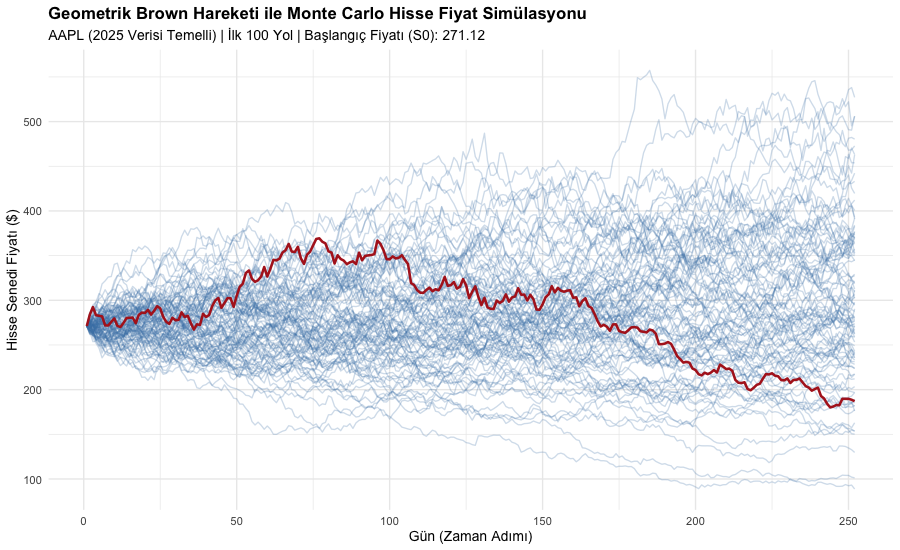

In [64]:
%%R -w 900 -h 550
library(ggplot2)
library(quantmod)

# 1. VERİ ÇEKME: 
hisse <- getSymbols("AAPL", from = "2025-01-01", to = "2026-01-01", auto.assign = FALSE)

# Sütun isimlerini standartlaştıralım (AAPL.Close yerine Close, AAPL.Adjusted yerine Adjusted vb.)
colnames(hisse) <- c("Open", "High", "Low", "Close", "Volume", "Adjusted")

# İlk birkaç satırı kontrol etme (İsteğe bağlı)
head(hisse)

# 2. Veri Hazırlığı ve Parametre Hesaplama
# Finansal analizlerde bölünme ve temettüleri hesaba katan 'Adjusted' (Düzeltilmiş) fiyatı kullanmak daha doğrudur
getiriler <- diff(log(hisse$Adjusted))[-1]  # Log getiriler ve ilk boş (NA) satırı atma

mu <- mean(getiriler, na.rm = TRUE) * 252
sigma <- sd(getiriler, na.rm = TRUE) * sqrt(252)
S0 <- as.numeric(tail(hisse$Adjusted, 1))
kaynak <- "AAPL (Yahoo Finance - quantmod)"

cat("Kaynak:", kaynak, "\n")
cat("S0 =", S0, ", μ(yıllık) =", mu, ", σ(yıllık) =", sigma, "\n")

n_simulasyon <- 2000
n_gun <- 252
dt <- 1/252

set.seed(7) 
fiyat_yollari <- matrix(0, nrow = n_simulasyon, ncol = n_gun)
fiyat_yollari[, 1] <- S0

# Geometrik Brown Hareketi Simülasyonu
for (t in 2:n_gun) {
    Z <- rnorm(n_simulasyon)
    fiyat_yollari[, t] <- fiyat_yollari[, t - 1] * exp((mu - sigma^2 / 2) * dt + sigma * sqrt(dt) * Z)
}

son_fiyatlar <- fiyat_yollari[, n_gun]
getiri_dagilimi <- (son_fiyatlar - S0) / S0

VaR_95 <- quantile(getiri_dagilimi, 0.05)
cat("\n1 Yıl Sonraki Beklenen Fiyat:", mean(son_fiyatlar), "\n")
cat("%95 VaR:", VaR_95, "(", VaR_95 * 100, "%) - yani %95 güvenle, kaybın bundan fazla olmaz\n")

# 3. Vektörel Hızlı Matris Dönüşümü (İlk 100 Simülasyon Yolu)
n_gosterilecek <- 100
matris_alt_kume <- fiyat_yollari[1:n_gosterilecek, ]

plot_data <- data.frame(
    Gun = rep(1:n_gun, each = n_gosterilecek),
    Simulasyon = rep(1:n_gosterilecek, times = n_gun),
    Fiyat = as.vector(matris_alt_kume)
)

# 4. GÖRSELLEŞTİRME
ggplot(plot_data, aes(x = Gun, y = Fiyat, group = Simulasyon)) +
    geom_line(alpha = 0.25, color = "steelblue") + 
    geom_line(data = subset(plot_data, Simulasyon == 1), aes(x = Gun, y = Fiyat), color = "firebrick", size = 1.2) + 
    labs(
        title = "Geometrik Brown Hareketi ile Monte Carlo Hisse Fiyat Simülasyonu",
        subtitle = paste("AAPL (2025 Verisi Temelli) | İlk 100 Yol | Başlangıç Fiyatı (S0):", round(S0, 2)),
        x = "Gün (Zaman Adımı)",
        y = "Hisse Senedi Fiyatı ($)"
    ) +
    theme_minimal(base_size = 14) +
    theme(plot.title = element_text(face = "bold"))


---
## 📚 Kaynaklar

| Kaynak | Bölüm | Notlar |
|---|---|---|
| [Prob4DS — Stanley Chan](https://probability4datascience.com) | Ch. 8.6 | Monte Carlo yöntemleri |
| [Harvard STAT 110](https://youtube.com/playlist?list=PL2SOU6wwxB0uwwH80KTQ6ht66KWxbzTIo) | — | LLN'nin uygulamaları |
| [Seeing Theory](https://seeing-theory.brown.edu/basic-probability) | Law of Large Numbers | İnteraktif Monte Carlo simülasyonu |
| [3Blue1Brown — Monte Carlo (π tahmini)](https://www.3blue1brown.com) | — | Görsel sezgi |
| [Kaggle — Medical Cost Personal Dataset](https://www.kaggle.com/datasets/mirichoi0218/insurance) | Veri | insurance.csv kaynağı |
| [yfinance Dokümantasyonu](https://pypi.org/project/yfinance/) | Kütüphane | Gerçek zamanlı hisse verisi |